In [1]:
import sys, pickle, random
import numpy as np
import librosa
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

sys.path.append('..')

with open("../data_prep/pkl-files/test_contours.pkl", "rb") as f:
    test_contours = pickle.load(f)

def resample_trajectory(freqs, n_points=100):
    if len(freqs) < 2:
        return None
    x_old = np.linspace(0, 1, len(freqs))
    x_new = np.linspace(0, 1, n_points)
    return interp1d(x_old, freqs, kind="linear")(x_new)

test_resampled_trajectories = []
test_keys = []
for key, data in test_contours.items():
    result = resample_trajectory(data["bottom_or_main"]["frequency_hz"])
    if result is not None:
        test_resampled_trajectories.append(result)
        test_keys.append(key)

print(f"{len(test_resampled_trajectories)} test trajectories, keys tracked")

2251 test trajectories, keys tracked


files with a time gap inside the bottom trajectory: jump subset = 47.8%, everything else = 26.8%


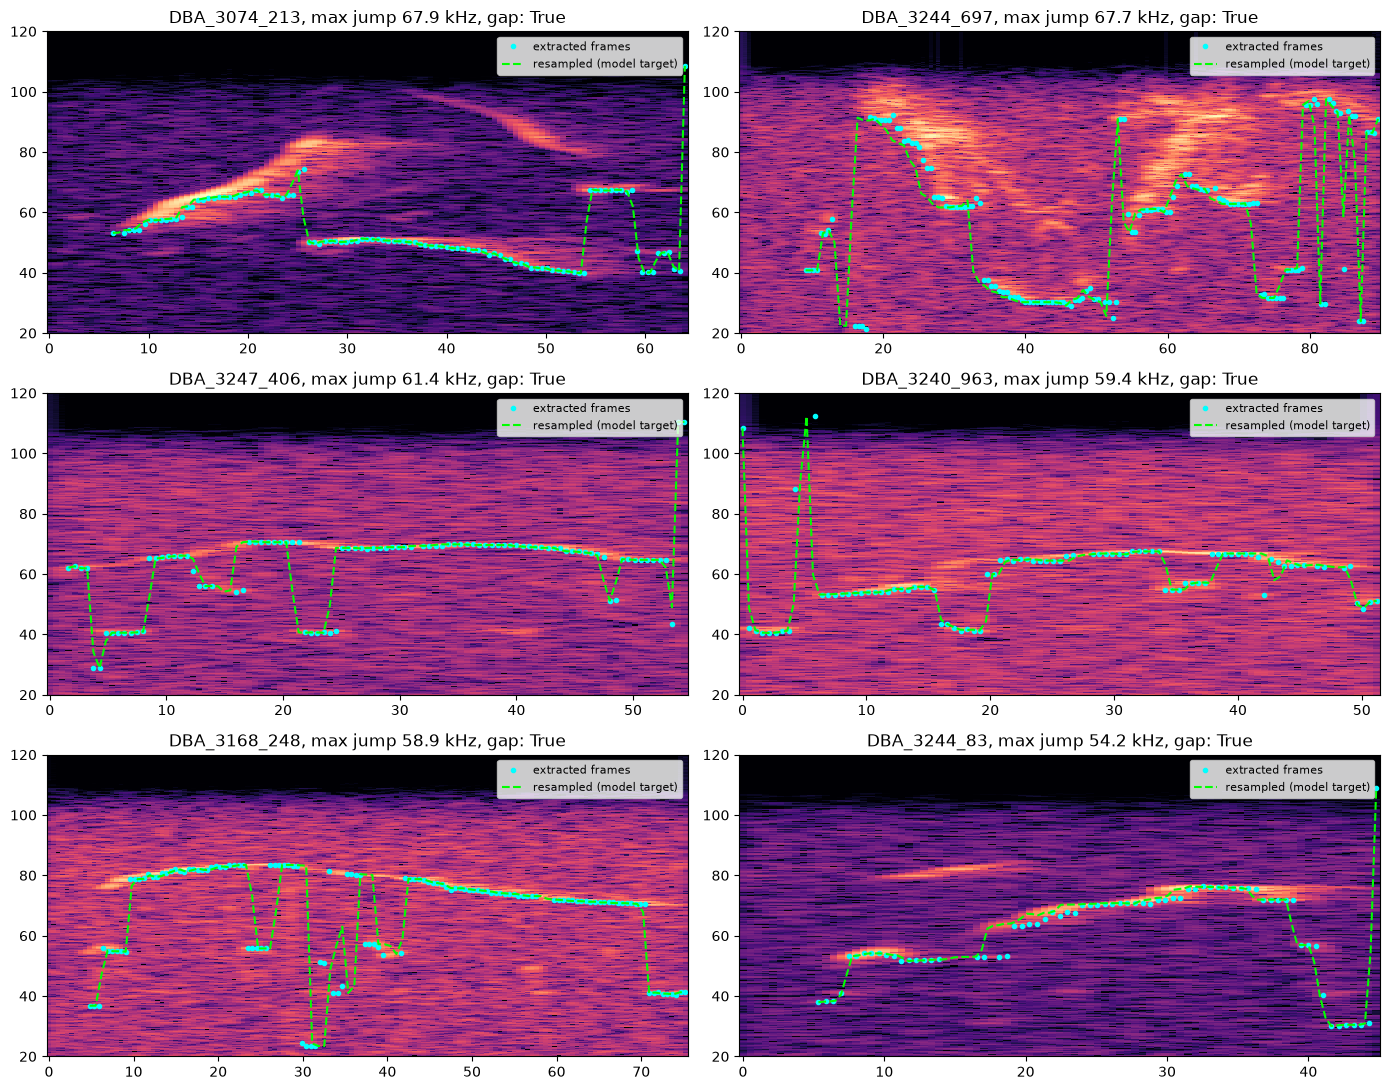

In [2]:
from data_prep.utils import find_audio_file, get_spectrogram

X = np.array(test_resampled_trajectories)
max_jump = np.max(np.abs(np.diff(X, axis=1)), axis=1)
jump = max_jump >= np.percentile(max_jump, 90)

hop_s = 128 / 240000  # frame spacing used in the extraction

def has_gap(key):
    t = test_contours[key]["bottom_or_main"]["time_s"]
    return bool(np.any(np.diff(t) > 1.5 * hop_s))

gaps = np.array([has_gap(k) for k in test_keys])
print(f"files with a time gap inside the bottom trajectory: "
      f"jump subset = {gaps[jump].mean():.1%}, everything else = {gaps[~jump].mean():.1%}")

worst = np.argsort(max_jump)[::-1][:6]
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for ax, idx in zip(axes.flatten(), worst):
    key = test_keys[idx]
    t, f, S = get_spectrogram(find_audio_file(key + ".WAV"), n_fft=1024, hop_length=128)
    ax.pcolormesh(t * 1000, f / 1000, librosa.amplitude_to_db(S, ref=np.max),
                  shading="auto", cmap="magma", vmin=-60, vmax=0)
    b = test_contours[key]["bottom_or_main"]
    ax.plot(b["time_s"] * 1000, b["frequency_hz"] / 1000, "o", color="cyan",
            markersize=3, label="extracted frames")
    t_res = np.linspace(b["time_s"].min(), b["time_s"].max(), X.shape[1]) * 1000
    ax.plot(t_res, X[idx] / 1000, color="lime", linewidth=1.5, linestyle="--",
            label="resampled (model target)")
    ax.set_ylim(20, 120)
    ax.set_title(f"{key}, max jump {max_jump[idx] / 1000:.1f} kHz, gap: {gaps[idx]}")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()